##### MDP

In [46]:
import numpy as np

S = 2  # Number of states
A = 2  # Number of actions
gamma = 0.9  # Discount factor
Rmin, Rmax = 0, 10  # Reward bounds

# Explicitly set rewards to ensure the optimal actions differ between states
R = np.array([9, 0])  # High reward for state 0, low reward for state 1

# Explicitly set transition probabilities P(s'|s, a) with shape (S, S', A)
P = np.zeros((S, S, A))

# Transition matrix for state 0, action 0 and action 1
P[0, :, 0] = [0.8, 0.2]  # Action 0 in state 0 transitions mostly to state 0
P[0, :, 1] = [0.3, 0.7]  # Action 1 in state 0 transitions mostly to state 1

# Transition matrix for state 1, action 0 and action 1
P[1, :, 0] = [0.4, 0.6]  # Action 0 in state 1 transitions mostly to state 1
P[1, :, 1] = [0.9, 0.1]  # Action 1 in state 1 transitions mostly to state 0

M = (S, A, R, gamma, P, Rmax, Rmin)

##### Value of arbitrary policy

In [47]:
# Generate a random deterministic policy pi(s) = a
pi = np.array([1,0])  # Random actions for each state

# Construct the transition matrix under the policy
P_pi = np.zeros((S, S))
for s in range(S):
    P_pi[s, :] = P[s, :, pi[s]]  # Extract transitions based on chosen actions by the policy for each s'

# Value Iteration for the policy
V = np.zeros(S)  # Initialize value function
tolerance = 1e-6  # Tolerance for convergence
delta = float('inf')

while delta > tolerance:
    V_new = R + gamma * P_pi @ V
    delta = np.max(np.abs(V_new - V))
    V = V_new

pi, P_pi, V

(array([1, 0]),
 array([[0.3, 0.7],
        [0.4, 0.6]]),
 array([37.98164295, 29.72476221]))

##### Value of deterministic policies

In [48]:
policies = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])  # 4 possible policies

# Initialize dict to store results
policy_results = {}

# Iterate over each policy
for i, pi in enumerate(policies):
    # Construct the transition matrix under the policy
    P_pi = np.zeros((S, S))
    for s in range(S):
        P_pi[s, :] = P[s, :, pi[s]]  # Extract transitions based on chosen actions by the policy

    # Value Iteration for the policy
    V = np.zeros(S)  # Initialize value function
    tolerance = 1e-6  # Tolerance for convergence
    delta = float('inf')

    while delta > tolerance:
        V_new = R + gamma * P_pi @ V
        delta = np.max(np.abs(V_new - V))
        V = V_new

    # Store the policy, transition matrix, and value function in the dict
    policy_results[f'Policy {pi}'] = {'P_pi': P_pi, 'V_pi': V}

# Print the results
for policy, results in policy_results.items():
    print(f"{policy}:")
    print(f"Transition Matrix P_pi:\n{results['P_pi']}")
    print(f"Value Function V_pi: {results['V_pi']}\n")

Policy [0 0]:
Transition Matrix P_pi:
[[0.8 0.2]
 [0.4 0.6]]
Value Function V_pi: [64.68749179 50.62499179]

Policy [0 1]:
Transition Matrix P_pi:
[[0.8 0.2]
 [0.9 0.1]]
Value Function V_pi: [75.13760651 66.88072578]

Policy [1 0]:
Transition Matrix P_pi:
[[0.3 0.7]
 [0.4 0.6]]
Value Function V_pi: [37.98164295 29.72476221]

Policy [1 1]:
Transition Matrix P_pi:
[[0.3 0.7]
 [0.9 0.1]]
Value Function V_pi: [53.18180963 47.33765378]



##### Value of policies (inversion)

In [49]:
# Initialize dict to store results for matrix inversion method
policy_results_matrix_inv = {}

# Iterate over each policy
for i, pi in enumerate(policies):
    # Construct the transition matrix under the policy
    P_pi = np.zeros((S, S))
    for s in range(S):
        P_pi[s, :] = P[s, :, pi[s]]  # Extract transitions based on chosen actions by the policy

    # Solve the Bellman equation using matrix inversion
    # V_pi = (I - gamma * P_pi)^(-1) * R
    I = np.eye(S)  # Identity matrix
    V_pi = np.linalg.inv(I - gamma * P_pi) @ R

    # Store the policy, transition matrix, and value function in the dict
    policy_results_matrix_inv[f'Policy {pi}'] = {'P_pi': P_pi, 'V_pi': V_pi}

# Print the results
for policy, results in policy_results_matrix_inv.items():
    print(f"{policy}:")
    print(f"Transition Matrix P_pi:\n{results['P_pi']}")
    print(f"Value Function V_pi (Matrix Inversion): {results['V_pi']}\n")

Policy [0 0]:
Transition Matrix P_pi:
[[0.8 0.2]
 [0.4 0.6]]
Value Function V_pi (Matrix Inversion): [64.6875 50.625 ]

Policy [0 1]:
Transition Matrix P_pi:
[[0.8 0.2]
 [0.9 0.1]]
Value Function V_pi (Matrix Inversion): [75.13761468 66.88073394]

Policy [1 0]:
Transition Matrix P_pi:
[[0.3 0.7]
 [0.4 0.6]]
Value Function V_pi (Matrix Inversion): [37.98165138 29.72477064]

Policy [1 1]:
Transition Matrix P_pi:
[[0.3 0.7]
 [0.9 0.1]]
Value Function V_pi (Matrix Inversion): [53.18181818 47.33766234]



##### Optimal Values and Optimal Policy

In [50]:
# Initialize the value function arbitrarily
V_opt = np.zeros(S)
tolerance = 1e-6
delta = float('inf')

# Optimal value iteration
while delta > tolerance:
    V_new = np.zeros(S)
    for s in range(S):
        # For each state, compute the maximum value across all actions
        V_new[s] = np.max([R[s] + gamma * np.dot(P[s, :, a], V_opt) for a in range(A)])
    delta = np.max(np.abs(V_new - V_opt))
    V_opt = V_new

# Compute the optimal Q function
Q_opt = np.zeros((S, A))
for s in range(S):
    for a in range(A):
        Q_opt[s, a] = R[s] + gamma * np.dot(P[s, :, a], V_opt)

# Extract the optimal policy by choosing the action with the highest Q value for each state
opt_pi = np.argmax(Q_opt, axis=1)

V_opt, Q_opt, opt_pi

(array([75.13760651, 66.88072578]),
 array([[75.13760733, 71.422011  ],
        [63.16513027, 66.8807266 ]]),
 array([0, 1]))

##### Checking optimality via Q-function

In [51]:
# Check the condition for each state
for s in range(S):
    optimal_action = opt_pi[s]
    for a in range(A):
        lhs = gamma * np.dot(P[s, :, optimal_action], V_opt)
        rhs = gamma * np.dot(P[s, :, a], V_opt)
        print(f"State {s}: Optimal action = {optimal_action}, Compared action = {a}")
        print(f"gamma * P_pi(s) * V_opt >= gamma * P_a(s) * V_opt: {lhs >= rhs}")

State 0: Optimal action = 0, Compared action = 0
gamma * P_pi(s) * V_opt >= gamma * P_a(s) * V_opt: True
State 0: Optimal action = 0, Compared action = 1
gamma * P_pi(s) * V_opt >= gamma * P_a(s) * V_opt: True
State 1: Optimal action = 1, Compared action = 0
gamma * P_pi(s) * V_opt >= gamma * P_a(s) * V_opt: True
State 1: Optimal action = 1, Compared action = 1
gamma * P_pi(s) * V_opt >= gamma * P_a(s) * V_opt: True


##### Checking optimality via value function

In [52]:
# Construct the transition matrix for the optimal policy
P_opt_pi = np.zeros((S, S))
for s in range(S):
    P_opt_pi[s, :] = P[s, :, opt_pi[s]]  # Transition matrix under optimal policy

# Check the matrix condition for each action
for a in range(A):
    P_a = np.zeros((S, S))
    for s in range(S):
        P_a[s, :] = P[s, :, a]  # Transition matrix under action a

    lhs = gamma * (P_opt_pi @ V_opt)
    rhs = gamma * (P_a @ V_opt)

    condition = np.all(lhs >= rhs)
    
    print(f"Checking action {a}:")
    print(f"gamma * P_opt_pi @ V_opt:\n{lhs}")
    print(f"gamma * P_a @ V_opt:\n{rhs}")
    print(f"Condition (P_opt_pi @ V_opt >= P_a @ V_opt): {condition}\n")

Checking action 0:
gamma * P_opt_pi @ V_opt:
[66.13760733 66.8807266 ]
gamma * P_a @ V_opt:
[66.13760733 63.16513027]
Condition (P_opt_pi @ V_opt >= P_a @ V_opt): True

Checking action 1:
gamma * P_opt_pi @ V_opt:
[66.13760733 66.8807266 ]
gamma * P_a @ V_opt:
[62.422011  66.8807266]
Condition (P_opt_pi @ V_opt >= P_a @ V_opt): True



##### checking optimality via matrix condition

In [53]:
# Construct the transition matrix for the optimal policy
P_opt_pi = np.zeros((S, S))
for s in range(S):
    P_opt_pi[s, :] = P[s, :, opt_pi[s]]  # Transition matrix under optimal policy

# Compute (I - gamma * P_opt_pi)^-1 * R
inverse_term = np.linalg.inv(I - gamma * P_opt_pi) @ R

# Check the condition (P_opt_pi - P_a) (I - gamma * P_opt_pi)^-1 * R >= 0 for each action
for a in range(A):
    P_a = np.zeros((S, S))
    for s in range(S):
        P_a[s, :] = P[s, :, a]  # Transition matrix under action a

    # Compute the left-hand side of the condition
    lhs = (P_opt_pi - P_a) @ inverse_term

    # Check if lhs >= 0
    condition = np.all(lhs >= 0)
    
    print(f"Checking action {a}:")
    print(f"(P_opt_pi - P_a) @ (I - gamma * P_opt_pi)^-1 * R:\n{lhs}")
    print(f"Condition: {condition}\n")

Checking action 0:
(P_opt_pi - P_a) @ (I - gamma * P_opt_pi)^-1 * R:
[0.         4.12844037]
Condition: True

Checking action 1:
(P_opt_pi - P_a) @ (I - gamma * P_opt_pi)^-1 * R:
[4.12844037 0.        ]
Condition: True



##### function to check if R is compatible with any optimal policy 

In [33]:
def check_optimal_policy_conditions(pi, R, gamma, P):
    S = len(R)  # Number of states
    A = P.shape[2]  # Number of actions
    I = np.eye(S)  # Identity matrix

    # Construct the transition matrix for the given policy
    P_opt_pi = np.zeros((S, S))
    for s in range(S):
        P_opt_pi[s, :] = P[s, :, pi[s]]  # Transition matrix under optimal policy

    # Compute (I - gamma * P_opt_pi)^-1 * R
    inverse_term = np.linalg.inv(I - gamma * P_opt_pi) @ R

    # Flag to check if all conditions are met
    all_conditions_met = True

    # Check the condition (P_opt_pi - P_a) (I - gamma * P_opt_pi)^-1 * R >= 0 for each action
    for a in range(A):
        P_a = np.zeros((S, S))
        for s in range(S):
            P_a[s, :] = P[s, :, a]  # Transition matrix under action a

        # Compute the left-hand side of the condition
        lhs = (P_opt_pi - P_a) @ inverse_term

        # Check if lhs >= 0
        condition = np.all(lhs >= 0)
        
        # If any condition fails, set the flag to False
        if not condition:
            all_conditions_met = False

    return all_conditions_met


check_optimal_policy_conditions(pi=[1, 0], R=[0, 1], gamma=0.9, P=P)

True

##### feasible rewards for an arbitrary policy (for it to be optimal)

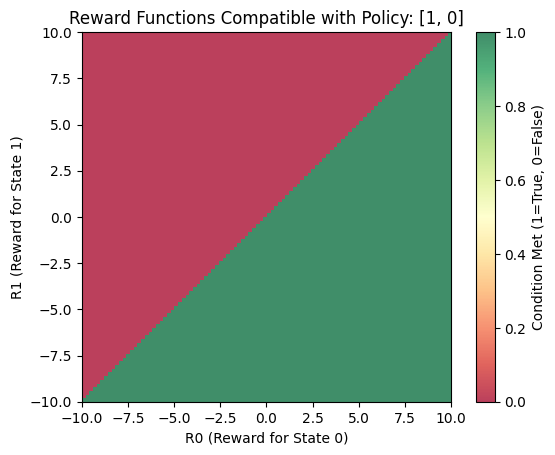

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Define function to check optimal policy conditions with rounding
def check_optimal_policy_conditions(pi, R, gamma, P, decimal_places=6):
    S = len(R)  # Number of states
    A = P.shape[2]  # Number of actions
    I = np.eye(S)  # Identity matrix

    # Construct the transition matrix for the given policy
    P_opt_pi = np.zeros((S, S))
    for s in range(S):
        P_opt_pi[s, :] = P[s, :, pi[s]]  # Transition matrix under optimal policy

    # Compute (I - gamma * P_opt_pi)^-1 * R and round the result
    inverse_term = np.linalg.inv(I - gamma * P_opt_pi) @ R
    inverse_term = np.round(inverse_term, decimals=decimal_places)

    # Flag to check if all conditions are met
    all_conditions_met = True

    # Check the condition (P_opt_pi - P_a) (I - gamma * P_opt_pi)^-1 * R >= 0 for each action
    for a in range(A):
        P_a = np.zeros((S, S))
        for s in range(S):
            P_a[s, :] = P[s, :, a]  # Transition matrix under action a

        # Compute the left-hand side of the condition and round the result
        lhs = (P_opt_pi - P_a) @ inverse_term
        lhs = np.round(lhs, decimals=decimal_places)

        # Check if lhs >= 0
        condition = np.all(lhs >= 0)
        
        # If any condition fails, set the flag to False
        if not condition:
            all_conditions_met = False

    return all_conditions_met

# Grid search over R with Rmin and Rmax
R_values = np.linspace(-Rmax, Rmax, 100)  # Create a grid of 100 values between -Rmax and Rmax
grid_results = np.zeros((len(R_values), len(R_values)))  # For storing condition results
pi = [1, 0]

# Search over all combinations of R[0] and R[1] in the grid
for i, r0 in enumerate(R_values):
    for j, r1 in enumerate(R_values):
        R = np.array([r0, r1])  # Set rewards for state 0 and state 1
        condition_met = check_optimal_policy_conditions(pi, R, gamma, P)
        grid_results[i, j] = condition_met

# Plot the results with updated title
plt.imshow(grid_results, extent=[-Rmax, Rmax, -Rmax, Rmax], origin='lower', cmap='RdYlGn', alpha=0.75)
plt.colorbar(label='Condition Met (1=True, 0=False)')
plt.xlabel('R0 (Reward for State 0)')
plt.ylabel('R1 (Reward for State 1)')
plt.title(f'Reward Functions Compatible with Policy: {pi}')
plt.show()

##### feasible rewards for all deterministic policies

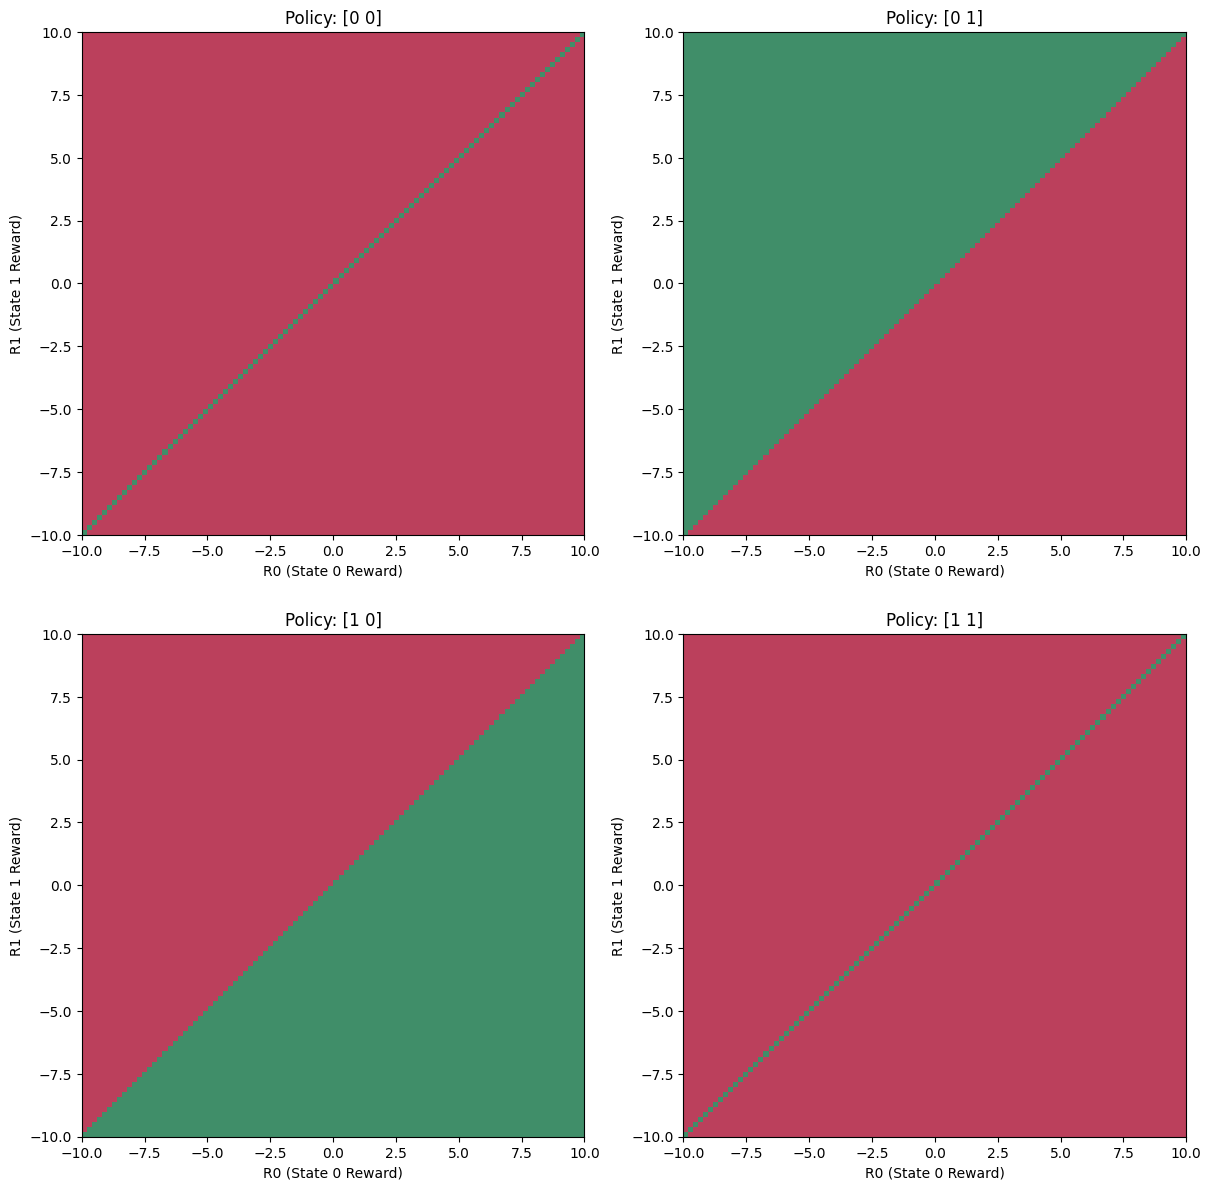

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Define function to check optimal policy conditions with rounding
def check_optimal_policy_conditions(pi, R, gamma, P, decimal_places=6):
    S = len(R)  # Number of states
    A = P.shape[2]  # Number of actions
    I = np.eye(S)  # Identity matrix

    # Construct the transition matrix for the given policy
    P_opt_pi = np.zeros((S, S))
    for s in range(S):
        P_opt_pi[s, :] = P[s, :, pi[s]]  # Transition matrix under optimal policy

    # Compute (I - gamma * P_opt_pi)^-1 * R and round the result
    inverse_term = np.linalg.inv(I - gamma * P_opt_pi) @ R
    inverse_term = np.round(inverse_term, decimals=decimal_places)

    # Flag to check if all conditions are met
    all_conditions_met = True

    # Check the condition (P_opt_pi - P_a) (I - gamma * P_opt_pi)^-1 * R >= 0 for each action
    for a in range(A):
        P_a = np.zeros((S, S))
        for s in range(S):
            P_a[s, :] = P[s, :, a]  # Transition matrix under action a

        # Compute the left-hand side of the condition and round the result
        lhs = (P_opt_pi - P_a) @ inverse_term
        lhs = np.round(lhs, decimals=decimal_places)

        # Check if lhs >= 0
        condition = np.all(lhs >= 0)
        
        # If any condition fails, set the flag to False
        if not condition:
            all_conditions_met = False

    return all_conditions_met

# Define the function to plot policy grid
def plot_policy_grid(M, num_points=100):
    # Unpack M to get S, A, R, gamma, P, Rmax, Rmin
    S, A, R, gamma, P, Rmax, Rmin = M

    # Create a grid of R values between Rmin and Rmax
    R_values = np.linspace(-Rmax, Rmax, num_points)
    policies = np.array(np.meshgrid(*[range(A)] * S)).T.reshape(-1, S)  # Generate all possible deterministic policies
    num_policies = len(policies)

    # Set up a 2x2 grid for plotting
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

    # Iterate over all possible policies
    for idx, pi in enumerate(policies):
        grid_results = np.zeros((len(R_values), len(R_values)))  # To store condition results

        # Search over all combinations of R[0] and R[1] in the grid
        for i, r0 in enumerate(R_values):
            for j, r1 in enumerate(R_values):
                R_test = np.array([r0, r1])  # Set rewards for state 0 and state 1
                condition_met = check_optimal_policy_conditions(pi, R_test, gamma, P)
                grid_results[i, j] = condition_met

        # Plot the results for this policy in the corresponding subplot
        ax = axs[idx // 2, idx % 2]  # Select correct subplot in 2x2 grid
        ax.imshow(grid_results, extent=[-Rmax, Rmax, -Rmax, Rmax], origin='lower', cmap='RdYlGn', alpha=0.75)
        ax.set_xlabel('R0 (State 0 Reward)')
        ax.set_ylabel('R1 (State 1 Reward)')
        ax.set_title(f'Policy: {pi}')

    plt.show()

# Example usage
plot_policy_grid(M)

##### The diff in return between optimal action and next best

In [37]:
def aggregate_q_difference(Q_opt, opt_pi):
    S, A = Q_opt.shape
    agg_sum = 0

    # Iterate over all states
    for s in range(S):
        optimal_action = opt_pi[s]
        # Compute Q(s, pi(s)) for the optimal action
        optimal_q_value = Q_opt[s, optimal_action]
        # Compute max_{a not pi(s)} Q(s, a)
        max_other_q_value = np.max([Q_opt[s, a] for a in range(A) if a != optimal_action])
        # Aggregate the difference
        agg_sum += (optimal_q_value - max_other_q_value)
    
    return agg_sum

# Example usage:
# Assuming Q_opt and opt_pi have been computed already
agg_q_difference = aggregate_q_difference(Q_opt, opt_pi)
agg_q_difference

7.431192660550472

##### the reward function that maximizes the diff between optimal and next best

In [45]:
import numpy as np

# Re-define the necessary functions

def aggregate_q_difference(Q_opt, opt_pi):
    """Compute the aggregate difference Q(s, pi(s)) - max_{a not pi(s)} Q(s, a)."""
    S, A = Q_opt.shape
    agg_sum = 0
    for s in range(S):
        optimal_action = opt_pi[s]
        # Compute Q(s, pi(s)) for the optimal action
        optimal_q_value = Q_opt[s, optimal_action]
        # Compute max_{a not pi(s)} Q(s, a)
        max_other_q_value = np.max([Q_opt[s, a] for a in range(A) if a != optimal_action])
        # Aggregate the difference
        agg_sum += (optimal_q_value - max_other_q_value)
    return agg_sum

def check_feasibility(pi, R, gamma, P):
    """Check if a given reward vector R is feasible."""
    S = len(R)
    I = np.eye(S)

    # Construct the transition matrix for the given policy
    P_opt_pi = np.zeros((S, S))
    for s in range(S):
        P_opt_pi[s, :] = P[s, :, pi[s]]  # Transition matrix under optimal policy

    # Compute the value function using matrix inversion
    V_opt = np.linalg.inv(I - gamma * P_opt_pi) @ R

    # Check if the policy is still feasible
    for s in range(S):
        for a in range(P.shape[2]):
            if a != pi[s]:
                if gamma * np.dot(P[s, :, pi[s]], V_opt) < gamma * np.dot(P[s, :, a], V_opt):
                    return False
    return True

def compute_Q_opt(V_opt, R, P, gamma):
    """Compute the Q_opt given V_opt, R, and P."""
    S, A = P.shape[0], P.shape[2]
    Q_opt = np.zeros((S, A))
    for s in range(S):
        for a in range(A):
            Q_opt[s, a] = R[s] + gamma * np.dot(P[s, :, a], V_opt)
    return Q_opt

def maximize_q_difference(P, gamma, R_min, R_max, opt_pi, num_points=10):
    """Maximize aggregate_q_difference within feasible rewards bounded by R_min and R_max."""
    S = P.shape[0]
    best_R = None
    best_q_diff = -np.inf

    # Grid search over R within bounds
    R_values = np.linspace(R_min, R_max, num_points)  # Create a grid for R

    for r0 in R_values:
        for r1 in R_values:
            R = np.array([r0, r1])

            # Check if the current R is feasible
            if check_feasibility(opt_pi, R, gamma, P):
                # Compute V_opt using matrix inversion
                P_opt_pi = np.zeros((S, S))
                for s in range(S):
                    P_opt_pi[s, :] = P[s, :, opt_pi[s]]
                V_opt = np.linalg.inv(np.eye(S) - gamma * P_opt_pi) @ R
                
                # Compute Q_opt
                Q_opt = compute_Q_opt(V_opt, R, P, gamma)
                
                # Calculate aggregate_q_difference
                q_diff = aggregate_q_difference(Q_opt, opt_pi)
                
                # Update the best R if we find a better q_diff
                if q_diff > best_q_diff:
                    best_q_diff = q_diff
                    best_R = R

    return best_R, best_q_diff

best_R, best_q_diff = maximize_q_difference(P, gamma, Rmin, Rmax, opt_pi)
print("Best R:", best_R)
print("Best Q Difference:", best_q_diff)

Best R: [10.  0.]
Best Q Difference: 8.256880733944968


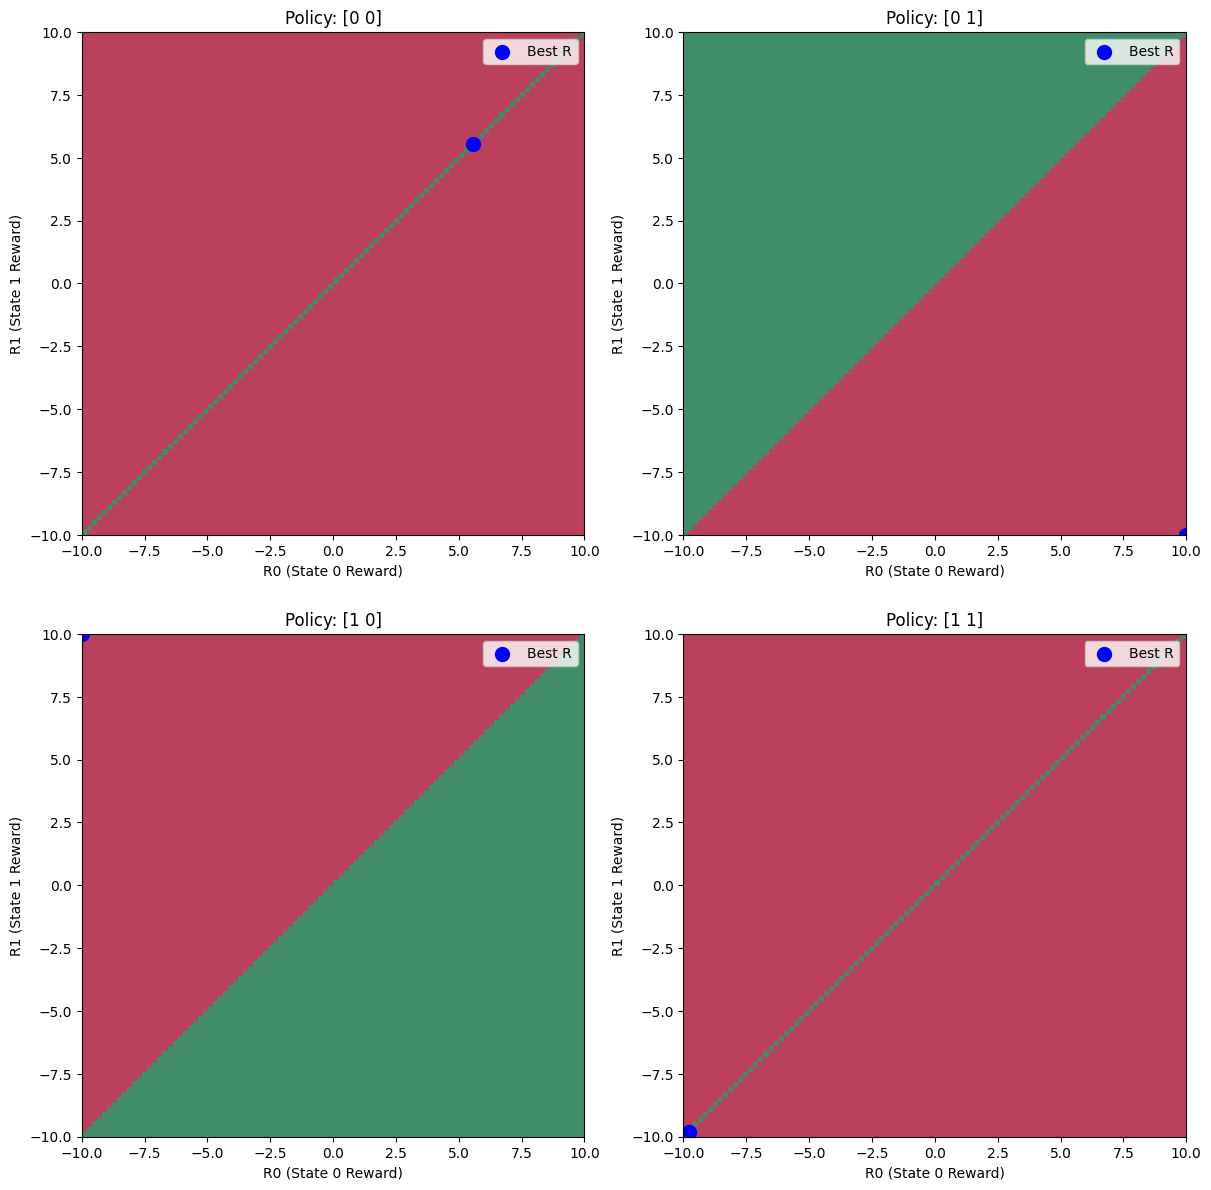

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Define function to check optimal policy conditions with rounding
def check_optimal_policy_conditions(pi, R, gamma, P, decimal_places=6):
    S = len(R)  # Number of states
    A = P.shape[2]  # Number of actions
    I = np.eye(S)  # Identity matrix

    # Construct the transition matrix for the given policy
    P_opt_pi = np.zeros((S, S))
    for s in range(S):
        P_opt_pi[s, :] = P[s, :, pi[s]]  # Transition matrix under optimal policy

    # Compute (I - gamma * P_opt_pi)^-1 * R and round the result
    inverse_term = np.linalg.inv(I - gamma * P_opt_pi) @ R
    inverse_term = np.round(inverse_term, decimals=decimal_places)

    # Flag to check if all conditions are met
    all_conditions_met = True

    # Check the condition (P_opt_pi - P_a) (I - gamma * P_opt_pi)^-1 * R >= 0 for each action
    for a in range(A):
        P_a = np.zeros((S, S))
        for s in range(S):
            P_a[s, :] = P[s, :, a]  # Transition matrix under action a

        # Compute the left-hand side of the condition and round the result
        lhs = (P_opt_pi - P_a) @ inverse_term
        lhs = np.round(lhs, decimals=decimal_places)

        # Check if lhs >= 0
        condition = np.all(lhs >= 0)
        
        # If any condition fails, set the flag to False
        if not condition:
            all_conditions_met = False

    return all_conditions_met

# Define the function to plot policy grid and mark the best R
def plot_policy_grid_with_best_R(M, num_points=100):
    # Unpack M to get S, A, R, gamma, P, Rmax, Rmin
    S, A, R, gamma, P, Rmax, Rmin = M

    # Create a grid of R values between Rmin and Rmax
    R_values = np.linspace(-Rmax, Rmax, num_points)
    policies = np.array(np.meshgrid(*[range(A)] * S)).T.reshape(-1, S)  # Generate all possible deterministic policies
    num_policies = len(policies)

    # Set up a 2x2 grid for plotting
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

    # Iterate over all possible policies
    for idx, pi in enumerate(policies):
        grid_results = np.zeros((len(R_values), len(R_values)))  # To store condition results
        best_R = None
        best_q_diff = -np.inf

        # Search over all combinations of R[0] and R[1] in the grid
        for i, r0 in enumerate(R_values):
            for j, r1 in enumerate(R_values):
                R_test = np.array([r0, r1])  # Set rewards for state 0 and state 1
                condition_met = check_optimal_policy_conditions(pi, R_test, gamma, P)
                grid_results[i, j] = condition_met

                # Compute Q difference and track the best R
                if condition_met:
                    # Compute the Q difference for this feasible R
                    P_opt_pi = np.zeros((S, S))
                    for s in range(S):
                        P_opt_pi[s, :] = P[s, :, pi[s]]
                    V_opt = np.linalg.inv(np.eye(S) - gamma * P_opt_pi) @ R_test
                    Q_opt = compute_Q_opt(V_opt, R_test, P, gamma)
                    q_diff = aggregate_q_difference(Q_opt, pi)
                    if q_diff > best_q_diff:
                        best_q_diff = q_diff
                        best_R = R_test

        # Plot the results for this policy in the corresponding subplot
        ax = axs[idx // 2, idx % 2]  # Select correct subplot in 2x2 grid
        ax.imshow(grid_results, extent=[-Rmax, Rmax, -Rmax, Rmax], origin='lower', cmap='RdYlGn', alpha=0.75)
        ax.set_xlabel('R0 (State 0 Reward)')
        ax.set_ylabel('R1 (State 1 Reward)')
        ax.set_title(f'Policy: {pi}')

        # Mark the best R
        if best_R is not None:
            ax.scatter(best_R[0], best_R[1], color='blue', s=100, label='Best R')
            ax.legend()

    plt.show()

# Example usage with the existing MDP environment
plot_policy_grid_with_best_R(M)

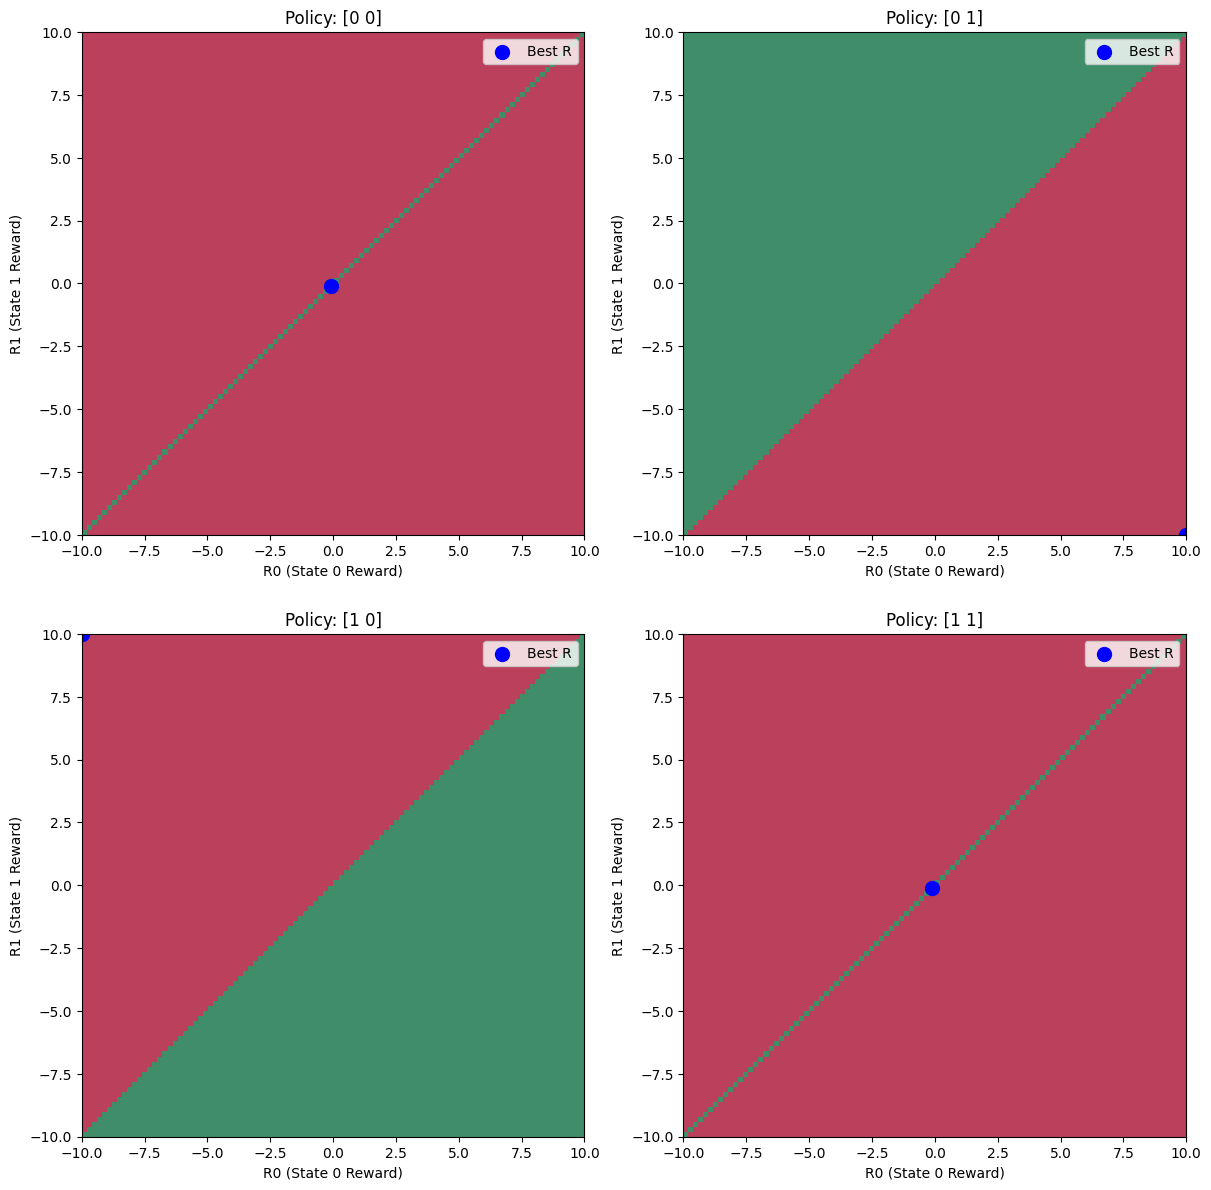

In [62]:
# Define the function to plot policy grid and mark the best R with regularization
def plot_policy_grid_with_best_R_and_regularization(M, num_points=100, lambda_reg=0.1):
    # Unpack M to get S, A, R, gamma, P, Rmax, Rmin
    S, A, R, gamma, P, Rmax, Rmin = M

    # Create a grid of R values between Rmin and Rmax
    R_values = np.linspace(-Rmax, Rmax, num_points)
    policies = np.array(np.meshgrid(*[range(A)] * S)).T.reshape(-1, S)  # Generate all possible deterministic policies
    num_policies = len(policies)

    # Set up a 2x2 grid for plotting
    fig, axs = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)

    # Iterate over all possible policies
    for idx, pi in enumerate(policies):
        grid_results = np.zeros((len(R_values), len(R_values)))  # To store condition results
        best_R = None
        best_q_diff = -np.inf

        # Search over all combinations of R[0] and R[1] in the grid
        for i, r0 in enumerate(R_values):
            for j, r1 in enumerate(R_values):
                R_test = np.array([r0, r1])  # Set rewards for state 0 and state 1
                condition_met = check_optimal_policy_conditions(pi, R_test, gamma, P)
                grid_results[i, j] = condition_met

                # Compute Q difference and track the best R with regularization
                if condition_met:
                    # Compute the Q difference for this feasible R
                    P_opt_pi = np.zeros((S, S))
                    for s in range(S):
                        P_opt_pi[s, :] = P[s, :, pi[s]]
                    V_opt = np.linalg.inv(np.eye(S) - gamma * P_opt_pi) @ R_test
                    Q_opt = compute_Q_opt(V_opt, R_test, P, gamma)
                    q_diff = aggregate_q_difference(Q_opt, pi) - lambda_reg * np.sum(np.abs(R_test))
                    
                    if q_diff > best_q_diff:
                        best_q_diff = q_diff
                        best_R = R_test

        # Plot the results for this policy in the corresponding subplot
        ax = axs[idx // 2, idx % 2]  # Select correct subplot in 2x2 grid
        ax.imshow(grid_results, extent=[-Rmax, Rmax, -Rmax, Rmax], origin='lower', cmap='RdYlGn', alpha=0.75)
        ax.set_xlabel('R0 (State 0 Reward)')
        ax.set_ylabel('R1 (State 1 Reward)')
        ax.set_title(f'Policy: {pi}')

        # Mark the best R
        if best_R is not None:
            ax.scatter(best_R[0], best_R[1], color='blue', s=100, label='Best R')
            ax.legend()

    plt.show()

# Example usage with regularization and the existing MDP environment
lambda_reg = 0.001  # Set the regularization parameter
plot_policy_grid_with_best_R_and_regularization(M, lambda_reg=lambda_reg)
